In [6]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import cross_val_predict, KFold, train_test_split
import matplotlib.pyplot as plt

np.random.seed(0)
N = 400

global_feat = np.random.randn(N, 8)
loc1 = np.random.randn(N, 20)   # H_τ1 analogu (örn. τ=100)
loc2 = np.random.randn(N, 15)   # H_τ2 analogu (τ=200)
loc3 = np.random.randn(N, 10)   # H_τ3 analogu (τ=400)

score = (global_feat[:,0] + 0.5*global_feat[:,1]
         - 0.8*loc1[:,0] + 0.6*loc2[:,0] + 0.4*loc3[:,0]
         + 0.3*np.random.randn(N))
y = (score > 0).astype(int)

(g_tr, g_val, l1_tr, l1_val, l2_tr, l2_val, l3_tr, l3_val, y_tr, y_val) = train_test_split(
    global_feat, loc1, loc2, loc3, y, test_size=0.3, random_state=0)

print("Eğitim/validation boyutları:", g_tr.shape[0], g_val.shape[0])

Eğitim/validation boyutları: 280 120


In [7]:
def train_layer_oof(X_train, y_train, n_splits=5, seed=0):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    learners = [
        RandomForestClassifier(n_estimators=100, random_state=seed),
        RandomForestClassifier(n_estimators=100, random_state=seed+1),
        ExtraTreesClassifier(n_estimators=100, random_state=seed),
        ExtraTreesClassifier(n_estimators=100, random_state=seed+1),
    ]
    oof_probs = []
    for m in learners:
        p = cross_val_predict(m, X_train, y_train, cv=kf, method="predict_proba")
        oof_probs.append(p)
    P_train_oof = np.hstack(oof_probs)

    fitted = []
    for m in learners:
        m.fit(X_train, y_train)
        fitted.append(m)
    return fitted, P_train_oof

def layer_predict(fitted_models, X):
    return np.hstack([m.predict_proba(X) for m in fitted_models])

def val_accuracy(P, y_true, n_learners=4, n_classes=2):
    avg = P.reshape(P.shape[0], n_learners, n_classes).mean(axis=1)
    return (avg.argmax(axis=1) == y_true).mean()

In [8]:
loc_list_train = [l1_tr, l2_tr, l3_tr]
loc_list_val   = [l1_val, l2_val, l3_val]
tau_names = ["τ=100(analog)", "τ=200(analog)", "τ=400(analog)"]

L_max = 8
accs = []
all_fitted_models = []
X_val_history = []      # <-- YENİ: her katmanın kendi X_val'ini sakla

X_train, X_val = None, None
P_prev_train, P_prev_val = None, None

for l in range(L_max):
    tau_idx = l % 3
    loc_train_l, loc_val_l = loc_list_train[tau_idx], loc_list_val[tau_idx]

    if l == 0:
        X_train = np.hstack([g_tr, loc_train_l])          # X0 (Eş. 31)
        X_val   = np.hstack([g_val, loc_val_l])
    else:
        X_train = np.hstack([P_prev_train, g_tr, loc_train_l])   # Xl (Eş. 32)
        X_val   = np.hstack([P_prev_val,   g_val, loc_val_l])

    fitted, P_train_oof = train_layer_oof(X_train, y_tr, seed=l)
    P_val = layer_predict(fitted, X_val)

    acc_l = val_accuracy(P_val, y_val)
    accs.append(acc_l)
    all_fitted_models.append(fitted)
    X_val_history.append(X_val)    # <-- YENİ: bu katmanın X_val'ini kaydet

    print(f"Katman {l} ({tau_names[tau_idx]}) | X shape: {X_train.shape} | val acc: {acc_l:.4f}")

    if l >= 2 and accs[l] <= accs[l-1] and accs[l] <= accs[l-2]:
        L_final = l - 1
        print(f"\n>>> Dynamic stopping tetiklendi: 2 katman üst üste iyileşme yok. Final L = {L_final}")
        break

    P_prev_train, P_prev_val = P_train_oof, P_val
else:
    L_final = L_max - 1
    print(f"\n>>> Lmax'a ulaşıldı. Final L = {L_final}")

Katman 0 (τ=100(analog)) | X shape: (280, 28) | val acc: 0.8000
Katman 1 (τ=200(analog)) | X shape: (280, 31) | val acc: 0.8083
Katman 2 (τ=400(analog)) | X shape: (280, 26) | val acc: 0.8583
Katman 3 (τ=100(analog)) | X shape: (280, 36) | val acc: 0.8667
Katman 4 (τ=200(analog)) | X shape: (280, 31) | val acc: 0.8417

>>> Dynamic stopping tetiklendi: 2 katman üst üste iyileşme yok. Final L = 3


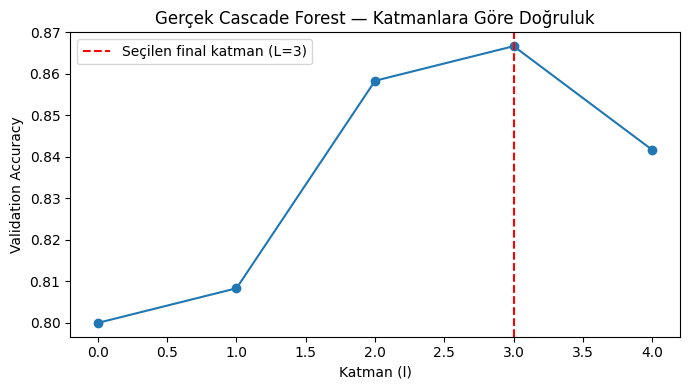

In [9]:
plt.figure(figsize=(7,4))
plt.plot(range(len(accs)), accs, 'o-')
plt.axvline(L_final, color='red', linestyle='--', label=f'Seçilen final katman (L={L_final})')
plt.xlabel("Katman (l)")
plt.ylabel("Validation Accuracy")
plt.title("Gerçek Cascade Forest — Katmanlara Göre Doğruluk")
plt.legend()
plt.tight_layout(); plt.show()

In [10]:
best_models = all_fitted_models[L_final]
X_val_for_best_layer = X_val_history[L_final]   # <-- DÜZELTME: son değil, DOĞRU katmanın X_val'i

final_probs = layer_predict(best_models, X_val_for_best_layer)
final_preds = final_probs.reshape(-1,4,2).mean(axis=1).argmax(axis=1)
final_acc = (final_preds == y_val).mean()
print(f"Final model doğruluğu (L={L_final}): {final_acc:.4f}")

# Sanity check: bu accuracy, Hücre 3'te o katman için zaten hesaplanan acc_l ile AYNI olmalı
print(f"Doğrulama (accs[{L_final}] ile eşleşmeli): {accs[L_final]:.4f}")

Final model doğruluğu (L=3): 0.8667
Doğrulama (accs[3] ile eşleşmeli): 0.8667
